In [3]:
!pip3 install --break-system-packages torch torchvision matplotlib scikit-learn seaborn pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 3.7 MB/s  0:00:00m 1.9 MB/s eta 0:00:01


Initializing dataset splitting...
-> Class 'Good': Split 665 images to Train, 167 images to Validation.
-> Class 'Defective': Split 692 images to Train, 174 images to Validation.
Dataset successfully split and organized inside 'dataset_split/'!

Execution Target Device: cpu

PyTorch DataLoaders successfully bound.
Mapped Classes: ['defective', 'good'] -> {'defective': 0, 'good': 1}

Epoch 1/15
Train Metrics -> Loss: 0.6143 Acc: 0.6772
Val Metrics -> Loss: 0.4795 Acc: 0.8680

Epoch 2/15
Train Metrics -> Loss: 0.4118 Acc: 0.8585
Val Metrics -> Loss: 0.3894 Acc: 0.8152

Epoch 3/15
Train Metrics -> Loss: 0.3036 Acc: 0.8836
Val Metrics -> Loss: 0.3201 Acc: 0.8534

Epoch 4/15
Train Metrics -> Loss: 0.2369 Acc: 0.9116
Val Metrics -> Loss: 0.2475 Acc: 0.8974

Epoch 5/15
Train Metrics -> Loss: 0.2165 Acc: 0.9182
Val Metrics -> Loss: 0.2327 Acc: 0.9062

Epoch 6/15
Train Metrics -> Loss: 0.2030 Acc: 0.9160
Val Metrics -> Loss: 0.2646 Acc: 0.8768

Epoch 7/15
Train Metrics -> Loss: 0.1948 Acc: 0.92

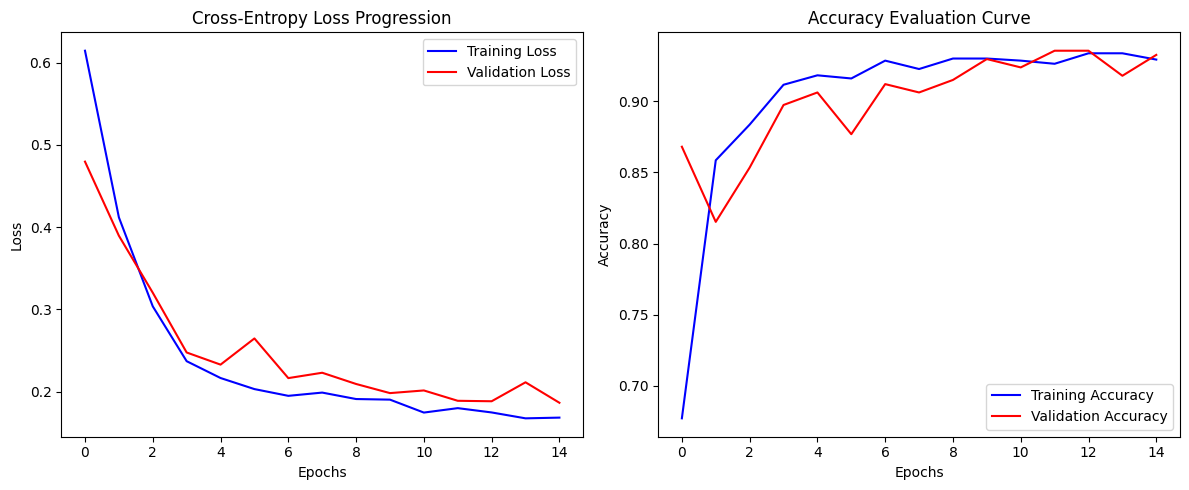

Classification Report Profile:
              precision    recall  f1-score   support

   defective       0.95      0.92      0.94       174
        good       0.92      0.95      0.94       167

    accuracy                           0.94       341
   macro avg       0.94      0.94      0.94       341
weighted avg       0.94      0.94      0.94       341



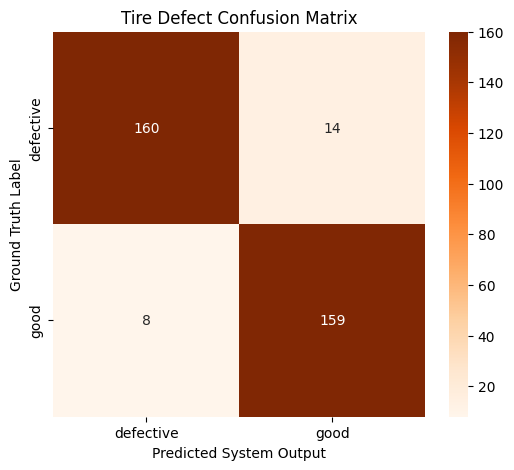

Model model parameters serialized and saved as: 'tire_defect_resnet18.pth'


In [ ]:
import os
import time
import copy
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# =====================================================================
# 1. DATASET SPLITTING LOGIC
# =====================================================================
ORIGINAL_DATA_DIR = 'dataset'  
SPLIT_DATA_DIR = 'dataset_split'
CLASSES = ['Good', 'Defective']
SPLIT_RATIO = 0.2  # 20% for validation, 80% for training

print("Initializing dataset splitting...")
for phase in ['train', 'val']:
    for cl in CLASSES:
        os.makedirs(os.path.join(SPLIT_DATA_DIR, phase, cl.lower()), exist_ok=True)

for cl in CLASSES:
    source_class_folder = os.path.join(ORIGINAL_DATA_DIR, cl)
    
    if not os.path.exists(source_class_folder):
        raise FileNotFoundError(f"Could not find folder: {source_class_folder}. Please ensure your dataset folder name matches.")

    all_images = [f for f in os.listdir(source_class_folder) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    train_imgs, val_imgs = train_test_split(all_images, test_size=SPLIT_RATIO, random_state=42, shuffle=True)
    
    def copy_images(image_list, phase):
        for img in image_list:
            src_path = os.path.join(source_class_folder, img)
            dst_path = os.path.join(SPLIT_DATA_DIR, phase, cl.lower(), img)
            shutil.copy(src_path, dst_path)

    copy_images(train_imgs, 'train')
    copy_images(val_imgs, 'val')
    print(f"-> Class '{cl}': Split {len(train_imgs)} images to Train, {len(val_imgs)} images to Validation.")

print("Dataset successfully split and organized inside 'dataset_split/'!\n")

# =====================================================================
# 2. HYPERPARAMETERS & GLOBAL CONFIGURATION
# =====================================================================
BATCH_SIZE = 64  
NUM_CLASSES = 2      
NUM_EPOCHS = 15
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Execution Target Device: {DEVICE}\n")

# =====================================================================
# 3. DATA TRANSFORMS & DATA LOADERS
# =====================================================================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),  
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    x: datasets.ImageFolder(os.path.join(SPLIT_DATA_DIR, x), data_transforms[x])
    for x in ['train', 'val']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"PyTorch DataLoaders successfully bound.")
print(f"Mapped Classes: {class_names} -> {image_datasets['train'].class_to_idx}\n")

# =====================================================================
# 4. TRANSFER LEARNING ARCHITECTURE BACKBONE
# =====================================================================
def initialize_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Freeze lower layers but keep layer4 dynamic to track custom tire features
    for name, param in model.named_parameters():
        if "layer4" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
            
    num_features = model.fc.in_features
    
    # Multi-layer classification head with Dropout 
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),  
        nn.Linear(256, NUM_CLASSES)
    )
    
    return model.to(DEVICE)

model = initialize_model()
criterion = nn.CrossEntropyLoss() 

# Differential Learning Rates with L2 Regularization (weight decay)
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-5}, 
    {'params': model.fc.parameters(), 'lr': 1e-4}       
], weight_decay=1e-4)

# LR Scheduler decaying learning rates by half every 4 epochs to settle peaks smoothly
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

# =====================================================================
# 5. MODEL TRAINING & VALIDATION PIPELINE
# =====================================================================
def train_defect_detector(model, criterion, optimizer, scheduler, num_epochs=15):
    start_time = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('=' * 20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()   

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Metrics -> Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        
        # Step the learning rate decay scheduler after completing the epoch
        scheduler.step()
        print()

    duration = time.time() - start_time
    print(f'Training phase resolved in {duration // 60:.0f}m {duration % 60:.0f}s')
    print(f'Peak Validation Accuracy: {best_acc:.4f}\n')

    model.load_state_dict(best_model_wts)
    return model, history

# Execute the engine
trained_model, training_history = train_defect_detector(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

# =====================================================================
# 6. PERFORMANCE GRAPH VISUALIZATION
# =====================================================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_history['train_loss'], label='Training Loss', color='b')
plt.plot(training_history['val_loss'], label='Validation Loss', color='r')
plt.title('Cross-Entropy Loss Progression')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_history['train_acc'], label='Training Accuracy', color='b')
plt.plot(training_history['val_acc'], label='Validation Accuracy', color='r')
plt.title('Accuracy Evaluation Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# =====================================================================
# 7. PERFORMANCE ANALYTICS & MATRIX EVALUATION
# =====================================================================
def execute_validation_analytics(model, dataloader):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())
            
    return np.array(y_true), np.array(y_pred)

true_labels, predicted_labels = execute_validation_analytics(trained_model, dataloaders['val'])

print("Classification Report Profile:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Ground Truth Label')
plt.xlabel('Predicted System Output')
plt.title('Tire Defect Confusion Matrix')
plt.show()

# =====================================================================
# 8. WEIGHT SERIALIZATION
# =====================================================================
OUTPUT_MODEL_NAME = 'tire_defect_resnet18.pth'
torch.save(trained_model.state_dict(), OUTPUT_MODEL_NAME)
print(f"Model model parameters serialized and saved as: '{OUTPUT_MODEL_NAME}'")

Target Evaluation Device: cpu
Model weights and sequence map serialized successfully.


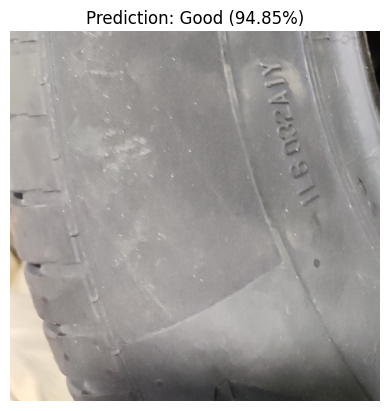

System Classification Result: Good
Confidence Level: 94.85%


In [6]:
import os
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP CONFIGURATION & LAYER CONFIG
# =====================================================================
MODEL_PATH = 'tire_defect_resnet18.pth'
IMAGE_PATH = 'good (2).jpg'  # Replace with your image file path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names must precisely match the alphabetical folder index mapping from training:
# Index 0 -> 'defective'
# Index 1 -> 'good'
CLASS_NAMES = ['Defective', 'Good']

# =====================================================================
# 2. LOAD THE SAVED MODEL ARCHITECTURE
# =====================================================================
def load_trained_model(model_path):
    # Recreate the exact architecture backbone used during training
    model = models.resnet18()
    num_features = model.fc.in_features
    
    # Must perfectly match the nn.Sequential block from your training script
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),  
        nn.Linear(256, len(CLASS_NAMES))
    )
    
    # Load the saved state dictionary weights
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()  # Crucial: Disables dropout and switches BatchNorm to evaluation mode
    return model

# =====================================================================
# 3. PREPROCESS THE TARGET IMAGE
# =====================================================================
# Replicates your validation pipeline transforms exactly
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_tire_defect(image_path, model):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Target image not found at: {image_path}")

    # Open image and convert to RGB (handles PNG transparency channels if present)
    image = Image.open(image_path).convert('RGB')
    
    # Apply preprocessing transformations and add an extra batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    input_tensor = inference_transforms(image).unsqueeze(0).to(DEVICE)
    
    # Pass image through network without computing gradients
    with torch.no_grad():
        outputs = model(input_tensor)
        
        # Apply Softmax along the class dimension to turn raw logits into confidence probabilities
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = CLASS_NAMES[predicted_idx.item()]
    confidence_score = confidence.item() * 100
    
    # Visual Output
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence_score:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"System Classification Result: {predicted_class}")
    print(f"Confidence Level: {confidence_score:.2f}%")
    return predicted_class, confidence_score

# =====================================================================
# 4. EXECUTION
# =====================================================================
try:
    print(f"Target Evaluation Device: {DEVICE}")
    # Initialize model weight map
    loaded_model = load_trained_model(MODEL_PATH)
    print("Model weights and sequence map serialized successfully.")
    
    # Execute Prediction
    predict_tire_defect(IMAGE_PATH, loaded_model)

except FileNotFoundError as e:
    print(f"\n[Error]: Check file paths or names. {e}")
except RuntimeError as e:
    print(f"\n[Error]: Architecture mismatch. Ensure this script mirrors your training code structure. Detail: {e}")

Target Evaluation Device: cpu
Model weights and sequence map serialized successfully.


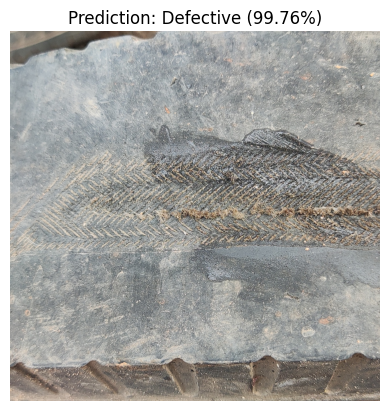

System Classification Result: Defective
Confidence Level: 99.76%


In [7]:
import os
import torch
import torch.nn as nn
from PIL import Image
from torchvision import transforms, models
import matplotlib.pyplot as plt

# =====================================================================
# 1. SETUP CONFIGURATION & LAYER CONFIG
# =====================================================================
MODEL_PATH = 'tire_defect_resnet18.pth'
IMAGE_PATH = 'Defective (14).jpg'  # Replace with your image file path
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names must precisely match the alphabetical folder index mapping from training:
# Index 0 -> 'defective'
# Index 1 -> 'good'
CLASS_NAMES = ['Defective', 'Good']

# =====================================================================
# 2. LOAD THE SAVED MODEL ARCHITECTURE
# =====================================================================
def load_trained_model(model_path):
    # Recreate the exact architecture backbone used during training
    model = models.resnet18()
    num_features = model.fc.in_features
    
    # Must perfectly match the nn.Sequential block from your training script
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),  
        nn.Linear(256, len(CLASS_NAMES))
    )
    
    # Load the saved state dictionary weights
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()  # Crucial: Disables dropout and switches BatchNorm to evaluation mode
    return model

# =====================================================================
# 3. PREPROCESS THE TARGET IMAGE
# =====================================================================
# Replicates your validation pipeline transforms exactly
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_tire_defect(image_path, model):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Target image not found at: {image_path}")

    # Open image and convert to RGB (handles PNG transparency channels if present)
    image = Image.open(image_path).convert('RGB')
    
    # Apply preprocessing transformations and add an extra batch dimension: [3, 224, 224] -> [1, 3, 224, 224]
    input_tensor = inference_transforms(image).unsqueeze(0).to(DEVICE)
    
    # Pass image through network without computing gradients
    with torch.no_grad():
        outputs = model(input_tensor)
        
        # Apply Softmax along the class dimension to turn raw logits into confidence probabilities
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        confidence, predicted_idx = torch.max(probabilities, 0)
        
    predicted_class = CLASS_NAMES[predicted_idx.item()]
    confidence_score = confidence.item() * 100
    
    # Visual Output
    plt.imshow(image)
    plt.title(f"Prediction: {predicted_class} ({confidence_score:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"System Classification Result: {predicted_class}")
    print(f"Confidence Level: {confidence_score:.2f}%")
    return predicted_class, confidence_score

# =====================================================================
# 4. EXECUTION
# =====================================================================
try:
    print(f"Target Evaluation Device: {DEVICE}")
    # Initialize model weight map
    loaded_model = load_trained_model(MODEL_PATH)
    print("Model weights and sequence map serialized successfully.")
    
    # Execute Prediction
    predict_tire_defect(IMAGE_PATH, loaded_model)

except FileNotFoundError as e:
    print(f"\n[Error]: Check file paths or names. {e}")
except RuntimeError as e:
    print(f"\n[Error]: Architecture mismatch. Ensure this script mirrors your training code structure. Detail: {e}")

In [9]:
# Export trained ResNet18 for deployment: TorchScript (scripted & traced) + ONNX
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = 'tire_defect_resnet18.pth'   # existing state_dict
IMG_SIZE = 224
ONNX_OPSET = 12
NUM_CLASSES = 2

def build_model(num_classes=2, device='cpu'):
    model = models.resnet18()
    num_features = model.fc.in_features
    
    # Must perfectly replicate the custom nn.Sequential head used during training
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),  
        nn.Linear(256, num_classes)
    )
    
    # Load the state dictionary weights
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()  # Crucial: Disables dropout layers so they aren't baked hard into deployment models
    return model

print("Initializing model architecture mapping...")
model = build_model(num_classes=NUM_CLASSES, device='cpu')

# dummy input for tracing/export (CPU)
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, dtype=torch.float32)

# 1) TorchScript - scripted
# Note: Scripting models with nn.Sequential heads works seamlessly in modern PyTorch versions.
try:
    scripted = torch.jit.script(model)
    scripted.save('tire_defect_resnet18_scripted.pt')
    print('Saved: tire_defect_resnet18_scripted.pt')
except Exception as e:
    print('TorchScript (script) failed:', e)

# 2) TorchScript - traced (Highly recommended for ResNet / CNN style architectures)
try:
    traced = torch.jit.trace(model, dummy)
    traced.save('tire_defect_resnet18_traced.pt')
    print('Saved: tire_defect_resnet18_traced.pt')
except Exception as e:
    print('TorchScript (trace) failed:', e)

# 3) ONNX export (CPU, dynamic batch size)
onnx_path = 'tire_defect_resnet18.onnx'
try:
    torch.onnx.export(
        model,
        dummy,
        onnx_path,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
        opset_version=ONNX_OPSET,
        do_constant_folding=True
    )
    print('Saved:', onnx_path)
except Exception as e:
    print('ONNX export failed:', e)

print('Export complete.')

Initializing model architecture mapping...
Saved: tire_defect_resnet18_scripted.pt
Saved: tire_defect_resnet18_traced.pt
ONNX export failed: No module named 'onnxscript'
Export complete.
